In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

In [2]:
df = pd.DataFrame({
    "ID":[1,2,3,4,5],
    "Nombre":["Juan","Maria","Pedro","Ana","Luis"],
    "Edad":[32,-28,40,35,50],
    "Salario":[50000,60000,None,55000,200000]
})

In [3]:
df

,ID,Nombre,Edad,Salario
0,1,Juan,32,50000.0
1,2,Maria,-28,60000.0
2,3,Pedro,40,NaN
3,4,Ana,35,55000.0
4,5,Luis,50,200000.0


In [4]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       5 non-null      int64  
 1   Nombre   5 non-null      object 
 2   Edad     5 non-null      int64  
 3   Salario  4 non-null      float64
dtypes: float64(1), int64(2), object(1)
memory usage: 292.0+ bytes


,ID,Edad,Salario
count,5.000000,5.00000,4.000000
mean,3.000000,25.80000,91250.000000
std,1.581139,30.84153,72614.851557
min,1.000000,-28.00000,50000.000000
25%,2.000000,32.00000,53750.000000
50%,3.000000,35.00000,57500.000000
75%,4.000000,40.00000,95000.000000
max,5.000000,50.00000,200000.000000


In [5]:
print(df.info())
print(df.isnull().sum())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       5 non-null      int64  
 1   Nombre   5 non-null      object 
 2   Edad     5 non-null      int64  
 3   Salario  4 non-null      float64
dtypes: float64(1), int64(2), object(1)
memory usage: 292.0+ bytes
None
ID         0
Nombre     0
Edad       0
Salario    1
dtype: int64
             ID      Edad        Salario
count  5.000000   5.00000       4.000000
mean   3.000000  25.80000   91250.000000
std    1.581139  30.84153   72614.851557
min    1.000000 -28.00000   50000.000000
25%    2.000000  32.00000   53750.000000
50%    3.000000  35.00000   57500.000000
75%    4.000000  40.00000   95000.000000
max    5.000000  50.00000  200000.000000


In [6]:
df["Edad"] = df["Edad"].abs()
df["Salario"] = df["Salario"].fillna(df["Salario"].median())
df

,ID,Nombre,Edad,Salario
0,1,Juan,32,50000.0
1,2,Maria,28,60000.0
2,3,Pedro,40,57500.0
3,4,Ana,35,55000.0
4,5,Luis,50,200000.0


In [7]:
Q1 = df["Salario"].quantile(0.25)
Q3 = df["Salario"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

df[(df["Salario"] < limite_inferior) | (df["Salario"] > limite_superior)]

Límite inferior: 47500.0
Límite superior: 67500.0


,ID,Nombre,Edad,Salario
4,5,Luis,50,200000.0


In [8]:
df = df[(df["Salario"] >= limite_inferior) & (df["Salario"] <= limite_superior)]

df

,ID,Nombre,Edad,Salario
0,1,Juan,32,50000.0
1,2,Maria,28,60000.0
2,3,Pedro,40,57500.0
3,4,Ana,35,55000.0


In [9]:
df = df.copy()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["Salario_Normalizado"] = scaler.fit_transform(df[["Salario"]])

df

,ID,Nombre,Edad,Salario,Salario_Normalizado
0,1,Juan,32,50000.0,0.00
1,2,Maria,28,60000.0,1.00
2,3,Pedro,40,57500.0,0.75
3,4,Ana,35,55000.0,0.50


In [10]:
df = df.copy()

df["Años_Hasta_Jubilacion"] = 65 - df["Edad"]

df

,ID,Nombre,Edad,Salario,Salario_Normalizado,Años_Hasta_Jubilacion
0,1,Juan,32,50000.0,0.00,33
1,2,Maria,28,60000.0,1.00,37
2,3,Pedro,40,57500.0,0.75,25
3,4,Ana,35,55000.0,0.50,30


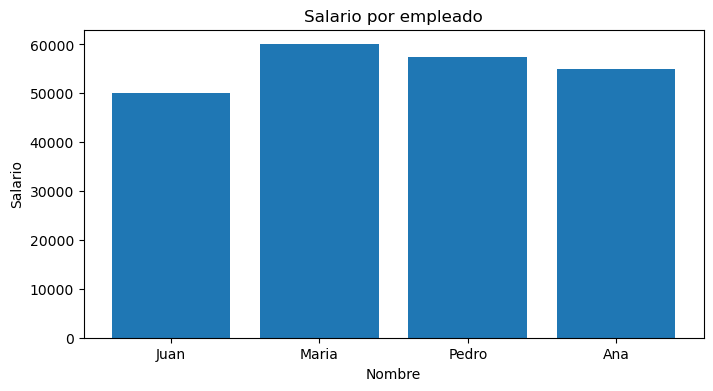

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(df["Nombre"], df["Salario"])
plt.title("Salario por empleado")
plt.xlabel("Nombre")
plt.ylabel("Salario")
plt.show()

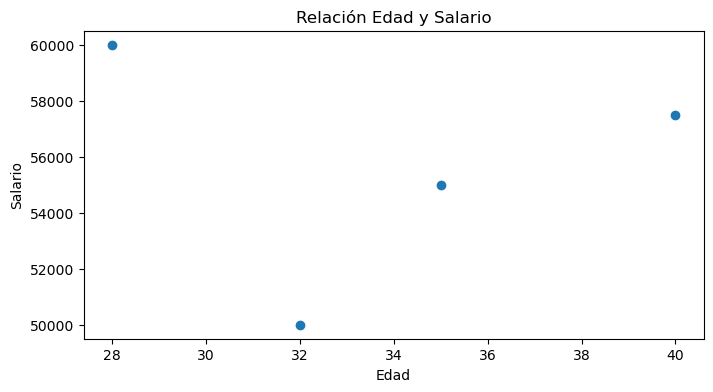

In [12]:
plt.figure(figsize=(8,4))
plt.scatter(df["Edad"], df["Salario"])
plt.title("Relación Edad y Salario")
plt.xlabel("Edad")
plt.ylabel("Salario")
plt.show()

## Interpretación de gráficos

El gráfico de barras muestra que María posee el salario más alto dentro del conjunto limpio, mientras Juan tiene el menor salario.

El gráfico de dispersión permite observar la relación entre edad y salario. En este conjunto pequeño no se aprecia una tendencia fuerte, aunque empleados de mayor edad tienden a salarios intermedios o altos.

In [13]:
df[["Edad","Salario","Salario_Normalizado","Años_Hasta_Jubilacion"]].corr()

,Edad,Salario,Salario_Normalizado,Años_Hasta_Jubilacion
Edad,1.00000,-0.06753,-0.06753,-1.00000
Salario,-0.06753,1.00000,1.00000,0.06753
Salario_Normalizado,-0.06753,1.00000,1.00000,0.06753
Años_Hasta_Jubilacion,-1.00000,0.06753,0.06753,1.00000


La correlación permite medir la relación entre variables numéricas. Se observa una relación negativa entre Edad y Años_Hasta_Jubilación, ya que mientras aumenta la edad, disminuyen los años restantes para jubilarse.

## Uso de LLM

Prompt utilizado:

"Tengo un dataset con salarios y edades. ¿Cómo detectar outliers en Python?"

Síntesis:

El modelo sugirió utilizar el método IQR para identificar valores extremos. Esta recomendación fue aplicada al dataset, detectando el salario de 200000 como valor atípico.

## Conclusión

El proceso de limpieza y transformación mejoró la calidad del dataset corrigiendo errores, imputando valores faltantes y eliminando valores extremos. Luego se aplicó normalización y análisis exploratorio para comprender mejor la relación entre variables.